In [56]:
import tensorflow as tf
from tensorflow import keras
fashion_mnist = keras.datasets.fashion_mnist
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2


In [2]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()
X_train_full.shape

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(60000, 28, 28)

In [3]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255. #o ponto em 255. caracteriza a conversao para float
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

In [7]:
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [92]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

# Compilar o modelo
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [93]:
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=45,
                    batch_size=256,
                    verbose=1)


Epoch 1/45
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5636 - loss: 1.4739 - val_accuracy: 0.8324 - val_loss: 0.6753
Epoch 2/45
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8171 - loss: 0.7141 - val_accuracy: 0.8485 - val_loss: 0.5746
Epoch 3/45
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8359 - loss: 0.6133 - val_accuracy: 0.8662 - val_loss: 0.5091
Epoch 4/45
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8477 - loss: 0.5439 - val_accuracy: 0.8647 - val_loss: 0.4723
Epoch 5/45
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8595 - loss: 0.4907 - val_accuracy: 0.8684 - val_loss: 0.4527
Epoch 6/45
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8630 - loss: 0.4618 - val_accuracy: 0.8753 - val_loss: 0.4172
Epoch 7/45
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8718 - loss: 0.4329 - val_accuracy: 0.8765 - val_loss: 0.4040
Epoch 8/45
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8782 - loss: 0.4041 - val_accu

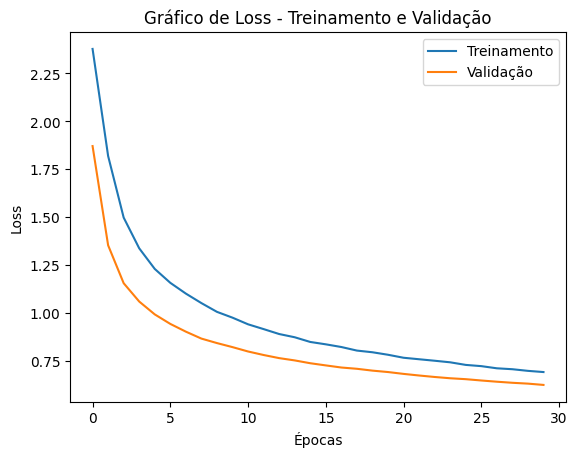

In [90]:
plt.plot(history.history['loss'], label='Treinamento')
plt.plot(history.history['val_loss'], label='Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.title('Gráfico de Loss - Treinamento e Validação')
plt.show()


In [91]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Acurácia no conjunto de teste: {test_accuracy * 100:.2f}%')

Acurácia no conjunto de teste: 84.82%
